In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score,f1_score
from pathlib import Path

In [77]:
# Load dataset

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
print(df.shape)

(891, 12)


In [78]:
# preprocess data

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Sex'] = df['Sex'].map({'male':0,'female':1})
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['isAlone'] = (df['FamilySize'] == 1).astype(int)
df['Fare_log'] = np.log(df['Fare']+1)

print(df.head(3))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    0  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0   
2                             Heikkinen, Miss. Laina    1  26.0      0      0   

             Ticket     Fare Cabin Embarked  FamilySize  isAlone  Fare_log  
0         A/5 21171   7.2500   NaN        S           2        0  2.110213  
1          PC 17599  71.2833   C85        C           2        0  4.280593  
2  STON/O2. 3101282   7.9250   NaN        S           1        1  2.188856  


In [79]:
# define features and target variable

features = ['Pclass', 'Sex', 'Age', 'Fare_log', 'FamilySize', 'isAlone']
X = np.array(df[features].values)
y = np.array(df['Survived'].values)
print(X.shape)
print(y.shape)

(891, 6)
(891,)


In [80]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42,stratify=y)

print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Testing set: {X_test.shape}, {y_test.shape}")

Training set: (712, 6), (712,)
Testing set: (179, 6), (179,)


In [81]:
# scale features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Mean of scaled training features:{X_train_scaled.mean(axis=0)[1]:.2f}")
print(f"Standard deviation of scaled training features: {X_train_scaled.std(axis=0)[1]:.2f}")


Mean of scaled training features:0.00
Standard deviation of scaled training features: 1.00


In [82]:
# train the model

model = LogisticRegression(C=1.0, random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)
print("Model trained")


for feature,weight in zip(features, model.coef_[0]):
    print(f"{feature}: {weight:.4f}")
    print(f"{feature} {'helps survival' if weight > 0 else 'hurts survival'}")

Model trained
Pclass: -0.6828
Pclass hurts survival
Sex: 1.2618
Sex helps survival
Age: -0.4856
Age hurts survival
Fare_log: 0.3984
Fare_log helps survival
FamilySize: -0.6124
FamilySize hurts survival
isAlone: -0.2304
isAlone hurts survival


In [83]:
# make prediction

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

print(y_pred.shape)
print(y_pred_proba.shape)

for i in range(5):
    print(f"Predicted class: {y_pred[i]}, Predicted probabilities: {y_pred_proba[i][1]}, True label: {y_test[i]}")

(179,)
(179, 2)
Predicted class: 0, Predicted probabilities: 0.12180206850700477, True label: 0
Predicted class: 0, Predicted probabilities: 0.07638581604754545, True label: 0
Predicted class: 0, Predicted probabilities: 0.11336777403430352, True label: 1
Predicted class: 0, Predicted probabilities: 0.05642965714016795, True label: 0
Predicted class: 1, Predicted probabilities: 0.6739179715140032, True label: 1


In [84]:
# evaluate the model

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall: {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.3f}")
print(f"\nClassification Report:\n", classification_report(y_test, y_pred,target_names=['Died', 'Survived']))

Accuracy: 0.810
Precision: 0.778
Recall: 0.710
F1 Score: 0.742

Classification Report:
               precision    recall  f1-score   support

        Died       0.83      0.87      0.85       110
    Survived       0.78      0.71      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



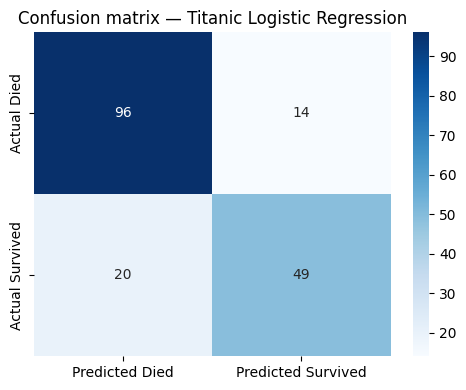

In [85]:
# confusion matrix chart

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['Predicted Died', 'Predicted Survived'],yticklabels=['Actual Died', 'Actual Survived'])
plt.title('Confusion matrix — Titanic Logistic Regression')
plt.tight_layout()
Path('outputs').mkdir(exist_ok=True)
plt.savefig('outputs/titanic_logistic_regression_confusion_matrix.png', dpi=150)
plt.show()



Pclass       -0.682811
FamilySize   -0.612368
Age          -0.485639
isAlone      -0.230438
Fare_log      0.398355
Sex           1.261845
dtype: float64


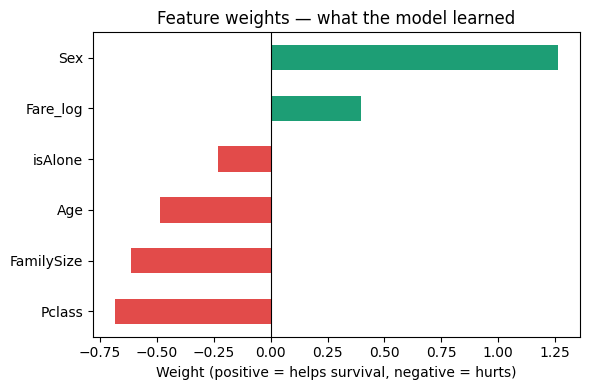

In [86]:
# feature weights chart

weights = pd.Series([weight for weight in model.coef_[0]], index=features).sort_values()
print(weights)
plt.figure(figsize=(6,4))
colors = ['#E24B4A' if weight < 0.0 else '#1D9E75' for weight in weights]
weights.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature weights — what the model learned')
plt.xlabel('Weight (positive = helps survival, negative = hurts)')
plt.tight_layout()
plt.savefig('outputs/titanic_logistic_regression_feature_weights.png', dpi=150)
plt.show()

In [87]:
# cross validation and save model

cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
for score in cv_scores:
    print(f"{score:.3f}")
print(f"Cross-validation score, mean: {cv_scores.mean():.3f}, std: {cv_scores.std():.3f}")

# save model
joblib.dump(model, 'outputs/titanic_logistic_regression_model.pkl')
joblib.dump(scaler, 'outputs/titanic_logistic_regression_scaler.pkl')

print("Model and scaler saved to 'outputs' folder")


# Run prediction on sample data

Jack =  [3, 0, 20, np.log(8), 1, 1]
Rose = [1, 1, 17, np.log(72), 3, 0]

scaled_Jack = scaler.transform([Jack])
scaled_Rose = scaler.transform([Rose])

Jack_pred_proba = model.predict_proba(scaled_Jack)
Rose_pred_proba = model.predict_proba(scaled_Rose)

print(f"Jack's predicted probability of survival: {Jack_pred_proba[0][1]:.3f}")
print(f"Rose's predicted probability of survival: {Rose_pred_proba[0][1]:.3f}")


0.776
0.755
0.817
0.803
0.803
Cross-validation score, mean: 0.791, std: 0.022
Model and scaler saved to 'outputs' folder
Jack's predicted probability of survival: 0.120
Rose's predicted probability of survival: 0.952
